# Notebook 02 - EDA Visualization (Insight Stage)

**Objective:** Perform Exploratory Data Analysis on the PlantVillage dataset to understand class distribution, detect imbalances, visualize sample images, and analyze environmental noise factors.

**Tasks:**
1. Load inventory from Stage 1
2. Analyze class distribution (detect imbalance)
3. Visualize sample images per class
4. Analyze environmental noise (brightness, contrast, blur)
5. Generate recommendations for preprocessing

**Input:** `data/metadata/inventory.csv` (from Stage 1)  
**Output:** EDA visualizations, statistics, and recommendations for preprocessing

## Import Packages

In [1]:
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from PIL import Image
import IPython

warnings.filterwarnings('ignore')

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})
sns.set_palette('husl')

print('Packages imported successfully')

Packages imported successfully


## Define Paths

In [2]:
# ── Define all project paths ─────────────────────────────────────────────────
from pathlib import Path
import os

def get_project_root():
    """Returns correct project root in both Jupyter and Colab."""
    if 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ:
        nb_dir = Path(os.getcwd())
    else:
        import IPython
        ip = IPython.get_ipython()
        nb_dir = Path(ip.run_line_magic('pwd', '')).resolve() if ip else Path('.').resolve()
    return nb_dir.parent

PROJECT_ROOT  = get_project_root()
DATA_DIR      = PROJECT_ROOT / 'data'
RAW_DIR       = DATA_DIR / 'raw' / 'plant_village'
METADATA_DIR  = DATA_DIR / 'metadata'
PROCESSED_DIR = DATA_DIR / 'processed'
PLOTS_DIR     = PROJECT_ROOT / 'reports' / 'figures'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'METADATA_DIR : {METADATA_DIR}')
print(f'Exists       : {METADATA_DIR.exists()}')


PROJECT_ROOT : /content/drive/MyDrive/Project2_AgroLens_AI
METADATA_DIR : /content/drive/MyDrive/Project2_AgroLens_AI/data/metadata
Exists       : True


## Load Inventory

In [3]:
## Load Inventory
inventory_path = METADATA_DIR / 'inventory.csv'

if not inventory_path.exists():
    print(f"\n❌ Error: {inventory_path} not found")
    print(f"   Please run Step 1 (01_image_acquisition.ipynb) first")
else:
    df = pd.read_csv(inventory_path)
    print(f"\n✓ Inventory loaded: {len(df):,} images")
    print(f"  Columns: {df.columns.tolist()}")


✓ Inventory loaded: 20,638 images
  Columns: ['path', 'filename', 'extension', 'label', 'crop', 'disease']


## Class Distribution Analysis
Analyze the dataset's composition, identifying the balance between different crops and diseases.

## Key Metrics

* Dataset Overview: Summary of total images, unique crops, and disease categories.
* Class Balance: Detection of data imbalance using the Imbalance Ratio ($Ratio = \frac{max\_count}{min\_count}$).
* Categorical Breakdown: Granular view of images per crop and disease type.

Note: High imbalance ratios (>5x) may require stratified sampling during the train-test split to ensure representative model evaluation.

In [4]:
if not df.empty:
    print("CLASS DISTRIBUTION ANALYSIS")
    print("="*80)
    
    # ── Basic statistics ──────────────────────────────────────────────────────────
    total_images = len(df)
    n_classes = df['label'].nunique()
    n_crops = df['crop'].nunique()
    n_diseases = df['disease'].nunique()
    
    print(f"\nDataset Overview:")
    print(f"  Total images    : {total_images:,}")
    print(f"  Total classes   : {n_classes}")
    print(f"  Unique crops    : {n_crops}")
    print(f"  Unique diseases : {n_diseases}")
    
    # ── Class distribution ────────────────────────────────────────────────────────
    class_counts = df['label'].value_counts().sort_values(ascending=False)
    imbalance_ratio = class_counts.max() / class_counts.min()
    
    print(f"\nClass Balance:")
    print(f"  Largest class   : {class_counts.idxmax()} ({class_counts.max():,} images)")
    print(f"  Smallest class  : {class_counts.idxmin()} ({class_counts.min():,} images)")
    print(f"  Imbalance ratio : {imbalance_ratio:.2f}x")
    
    if imbalance_ratio > 5:
        print(f"  ⚠️  WARNING: HIGH IMBALANCE (>5x) - May need stratified splitting")
    elif imbalance_ratio > 2:
        print(f"  ⚠️  CAUTION: Moderate imbalance (2-5x)")
    else:
        print(f"  ✓ Well-balanced dataset")
    
    # ── Crop distribution ────────────────────────────────────────────────────────
    print(f"\nImages per Crop:")
    crop_counts = df['crop'].value_counts().sort_values(ascending=False)
    for crop, count in crop_counts.items():
        pct = (count / total_images) * 100
        print(f"  {crop:20} : {count:5,} ({pct:5.1f}%)")
    
    # ── Disease distribution ──────────────────────────────────────────────────────
    print(f"\nImages per Disease (top 10):")
    disease_counts = df['label'].value_counts().head(10)
    for disease, count in disease_counts.items():
        pct = (count / total_images) * 100
        print(f"  {disease:45} : {count:5,} ({pct:5.1f}%)")

CLASS DISTRIBUTION ANALYSIS

Dataset Overview:
  Total images    : 20,638
  Total classes   : 15
  Unique crops    : 3
  Unique diseases : 10

Class Balance:
  Largest class   : Tomato__Tomato_YellowLeaf__Curl_Virus (3,208 images)
  Smallest class  : Potato___healthy (152 images)
  Imbalance ratio : 21.11x
  ⚠️  WARNING: HIGH IMBALANCE (>5x) - May need stratified splitting

Images per Crop:
  Tomato               : 16,011 ( 77.6%)
  Pepper               : 2,475 ( 12.0%)
  Potato               : 2,152 ( 10.4%)

Images per Disease (top 10):
  Tomato__Tomato_YellowLeaf__Curl_Virus         : 3,208 ( 15.5%)
  Tomato_Bacterial_spot                         : 2,127 ( 10.3%)
  Tomato_Late_blight                            : 1,909 (  9.2%)
  Tomato_Septoria_leaf_spot                     : 1,771 (  8.6%)
  Tomato_Spider_mites_Two_spotted_spider_mite   : 1,676 (  8.1%)
  Tomato_healthy                                : 1,591 (  7.7%)
  Pepper__bell___healthy                        : 1,478 (  7.2%)


## Class Distribution Visualization
A comprehensive graphical breakdown of the dataset to identify patterns, bias, and distribution density.

Visual Breakdown:

   1. Class Distribution (Horizontal): A full ranking of all disease classes to visualize the specific frequency of each label.
   2. Crop Share (Pie Chart): A proportional view of how the dataset is split between different host plants (e.g., Potato vs. Tomato).
   3. Top 15 Diseases: A focused bar chart highlighting the most prevalent conditions in the dataset.
   4. Density Analysis (Histogram): A frequency plot showing the "Images per Class" distribution, marked with Mean and Median to quantify the severity of the long-tail effect.

*Output:* Figures are automatically exported to 01_eda_class_distribution.png for use in reports.


✓ Saved: /content/drive/MyDrive/Project2_AgroLens_AI/reports/figures/01_eda_class_distribution.png


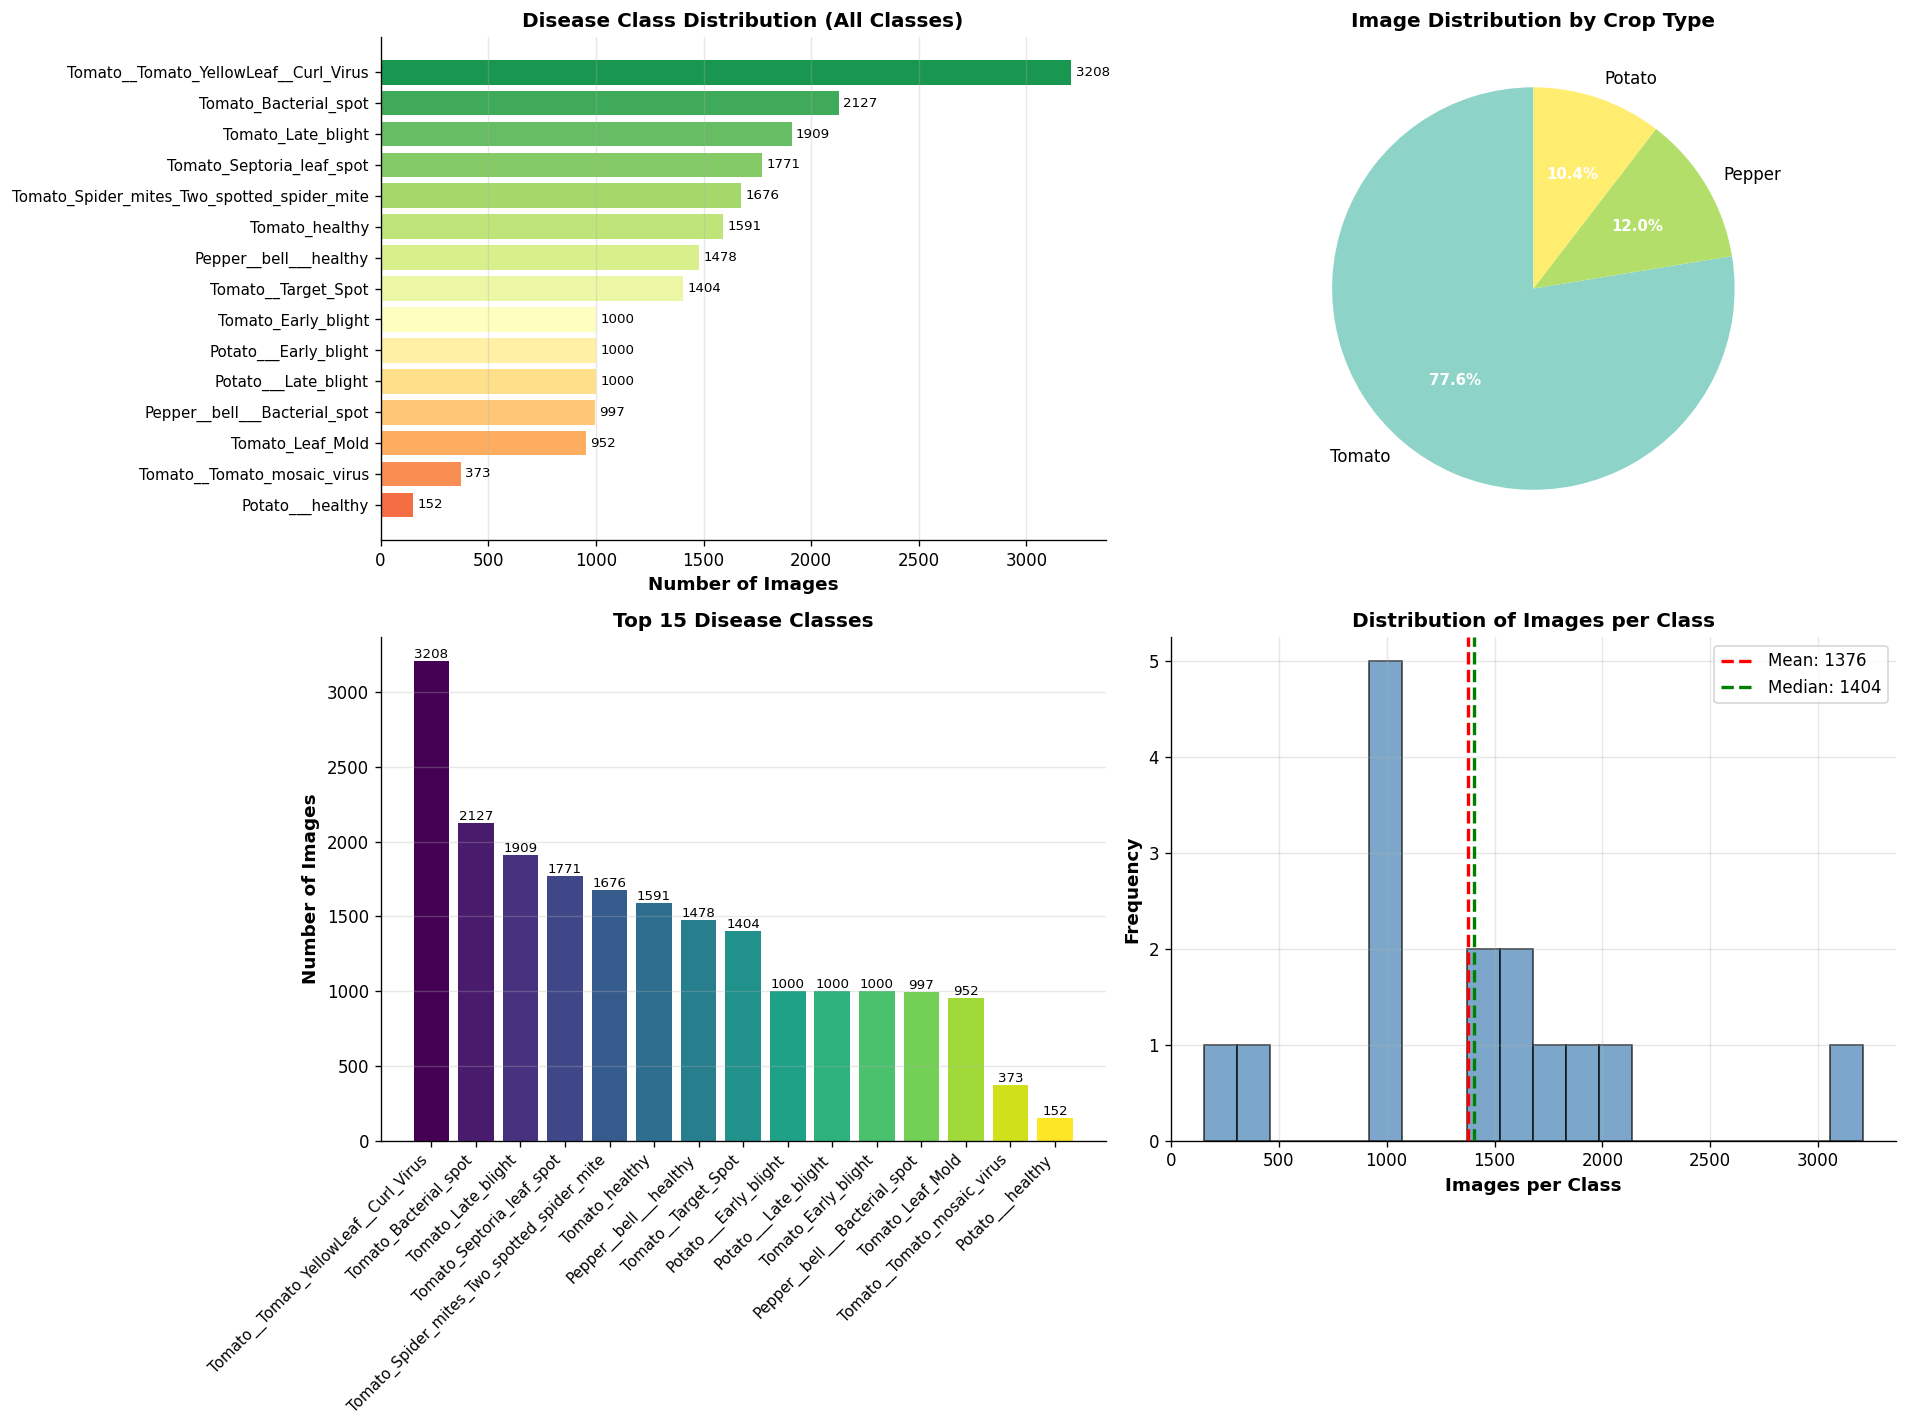

In [5]:
if not df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # ── 1. Horizontal bar chart (all disease classes) ──────────────────────────────
    ax = axes[0, 0]
    class_counts_sorted = df['label'].value_counts().sort_values()
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(class_counts_sorted)))
    ax.barh(range(len(class_counts_sorted)), class_counts_sorted.values, color=colors)
    ax.set_yticks(range(len(class_counts_sorted)))
    ax.set_yticklabels(class_counts_sorted.index, fontsize=9)
    ax.set_xlabel('Number of Images', fontsize=11, fontweight='bold')
    ax.set_title('Disease Class Distribution (All Classes)', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add count labels
    for i, v in enumerate(class_counts_sorted.values):
        ax.text(v + 20, i, str(v), va='center', fontsize=8)
    
    # ── 2. Crop distribution (pie chart) ─────────────────────────────────────────
    ax = axes[0, 1]
    crop_counts = df['crop'].value_counts()
    colors_crop = plt.cm.Set3(np.linspace(0, 1, len(crop_counts)))
    wedges, texts, autotexts = ax.pie(
        crop_counts.values,
        labels=crop_counts.index,
        autopct='%1.1f%%',
        colors=colors_crop,
        startangle=90
    )
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(9)
    ax.set_title('Image Distribution by Crop Type', fontsize=12, fontweight='bold')
    
    # ── 3. Top 15 disease classes (bar chart) ─────────────────────────────────────
    ax = axes[1, 0]
    top_15 = df['label'].value_counts().head(15)
    bars = ax.bar(range(len(top_15)), top_15.values, color=plt.cm.viridis(np.linspace(0, 1, 15)))
    ax.set_xticks(range(len(top_15)))
    ax.set_xticklabels(top_15.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Number of Images', fontsize=11, fontweight='bold')
    ax.set_title('Top 15 Disease Classes', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    # ── 4. Class imbalance analysis ──────────────────────────────────────────────
    ax = axes[1, 1]
    class_stats = df['label'].value_counts()
    ax.hist(class_stats.values, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(class_stats.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {class_stats.mean():.0f}')
    ax.axvline(class_stats.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {class_stats.median():.0f}')
    ax.set_xlabel('Images per Class', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Distribution of Images per Class', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plot_path = PLOTS_DIR / '01_eda_class_distribution.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: {plot_path}")
    plt.show()

## Image Visualization per Disease Class


✓ Saved: /content/drive/MyDrive/Project2_AgroLens_AI/reports/figures/02_eda_sample_images_per_class.png
  Loaded: 45, Failed: 0


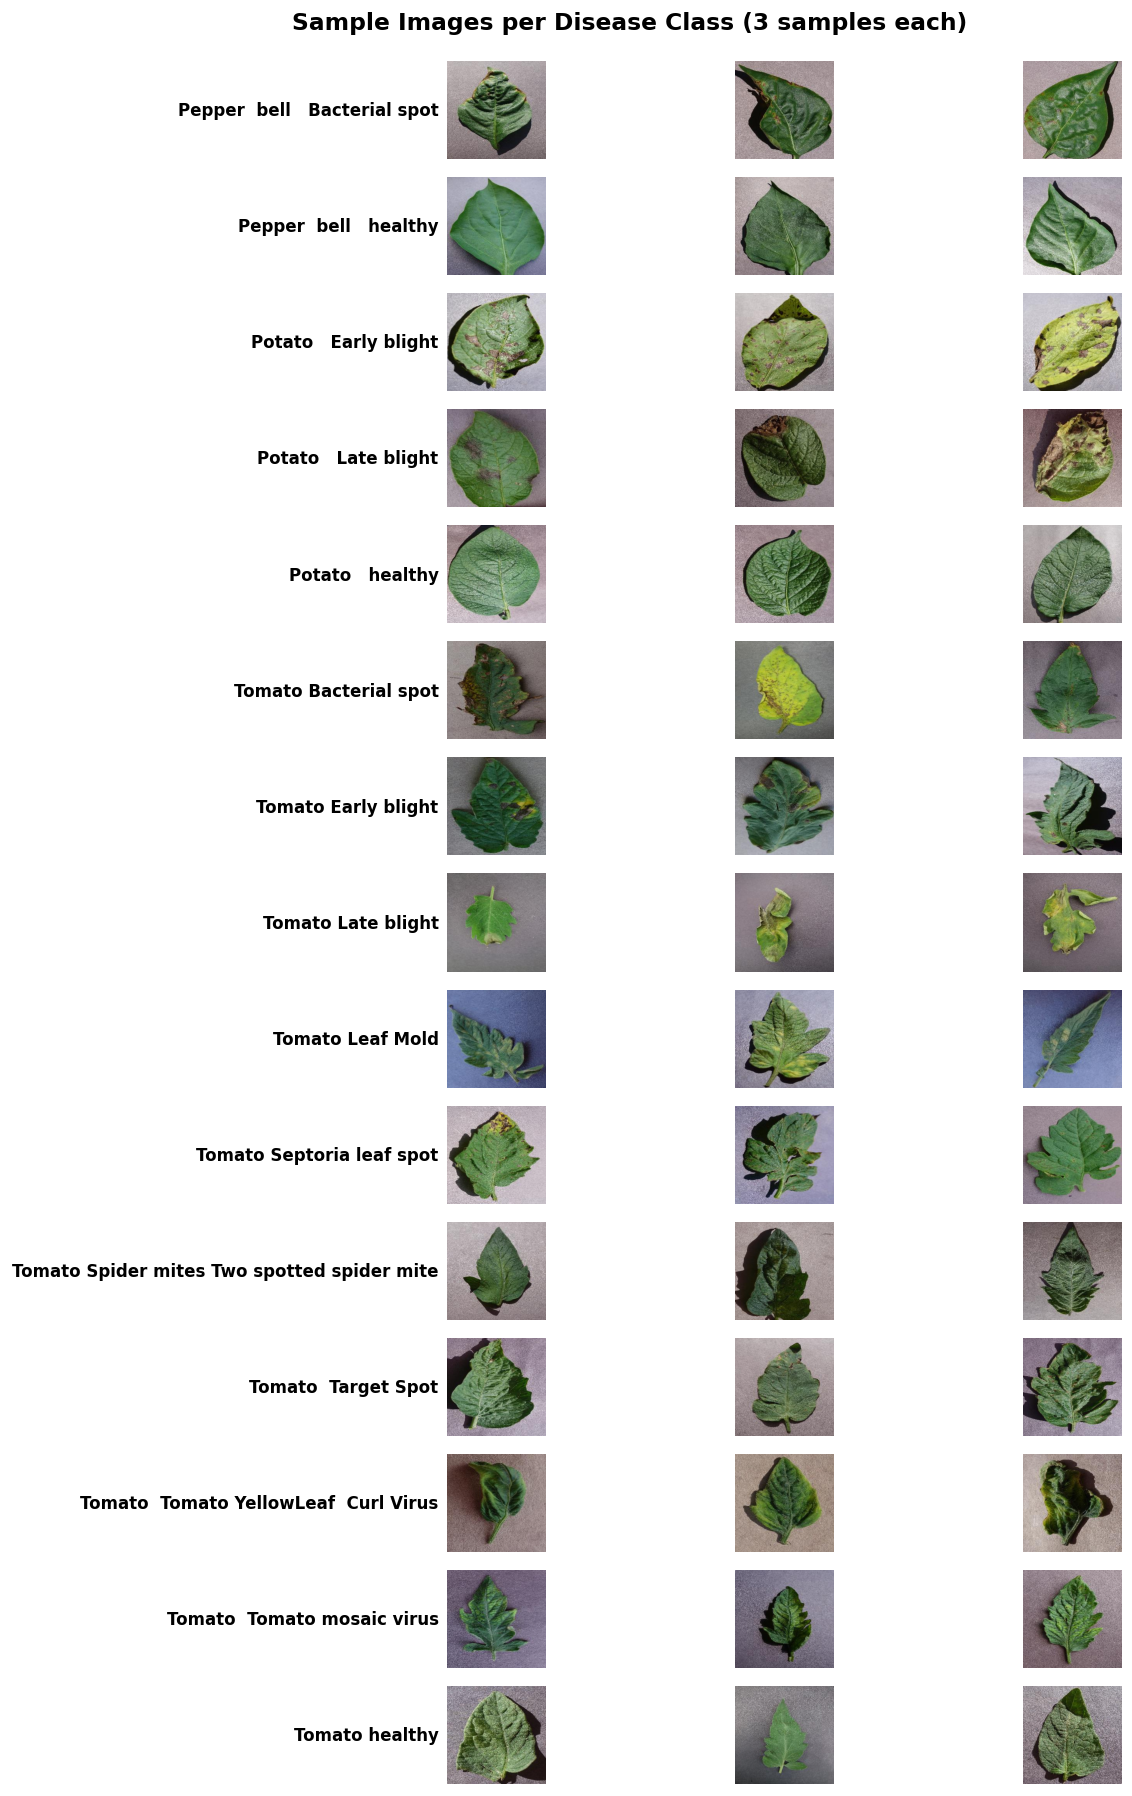

In [6]:
def load_image_safe(path: str, size: tuple = (224, 224)) -> np.ndarray:
    """
    Safely load and resize an image.
    
    Args:
        path: Path to image file
        size: Target size (width, height)
    
    Returns:
        Resized image array in RGB format, or None if load fails
    """
    try:
        p = Path(path)
        if not p.exists():
            return None
        
        img = cv2.imread(str(p))
        if img is None:
            return None
        
        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Resize
        img = cv2.resize(img, size, interpolation=cv2.INTER_LANCZOS4)
        
        return img
    except Exception as e:
        print(f"⚠️  Error loading {path}: {e}")
        return None


if not df.empty:
    # Select unique disease classes
    unique_diseases = df['label'].unique()
    n_samples_per_class = 3
    
    # Create figure
    n_cols = n_samples_per_class
    n_rows = len(unique_diseases)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, max(3, n_rows)))
    
    # Ensure axes is 2D
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    loaded_count = 0
    failed_count = 0
    
    # Iterate through each disease class
    for row, disease in enumerate(unique_diseases):
        # Get sample images for this disease
        disease_images = df[df['label'] == disease]['path'].sample(
            min(n_samples_per_class, len(df[df['label'] == disease]))
        ).tolist()
        
        # Display images in row
        for col, img_path in enumerate(disease_images):
            ax = axes[row, col]
            
            # Load image
            img = load_image_safe(img_path, size=(224, 224))
            
            if img is not None:
                ax.imshow(img)
                loaded_count += 1
            else:
                ax.imshow(np.zeros((224, 224, 3), dtype=np.uint8))
                ax.text(112, 112, '❌ Failed', ha='center', va='center',
                       color='red', fontsize=10, fontweight='bold')
                failed_count += 1
            
            ax.axis('off')
        
        # Add disease label on first column
        axes[row, 0].text(-20, 112, disease.replace('_', ' '), 
                          ha='right', va='center', fontsize=10, fontweight='bold')
    
    fig.suptitle(f'Sample Images per Disease Class (3 samples each)', 
                fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plot_path = PLOTS_DIR / '02_eda_sample_images_per_class.png'
    plt.savefig(plot_path, dpi=200, bbox_inches='tight')
    print(f"\n✓ Saved: {plot_path}")
    print(f"  Loaded: {loaded_count}, Failed: {failed_count}")
    plt.show()

## Image Quality Analysis (Environmental Noise)
**Goal:** Detects out-of-focus, overexposed, or inconsistently sized images before training.

**Metrics:** Calculates brightness, contrast, blur scores (Laplacian variance), and aspect ratios.


In [7]:
def compute_image_stats(path: str) -> dict:
    """
    Compute per-image statistics:
      - mean_brightness: average pixel luminance (0–255)
      - std_brightness: pixel std dev (proxy for contrast/noise)
      - blur_score: Laplacian variance (lower = blurrier)
      - aspect_ratio: width / height
    
    Returns:
        dict with computed stats, or None if load fails
    """
    try:
        p = Path(path)
        if not p.exists():
            return None
        
        img_bgr = cv2.imread(str(p))
        if img_bgr is None:
            return None
        
        h, w = img_bgr.shape[:2]
        
        # Convert to grayscale for brightness analysis
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        
        # Brightness statistics
        mean_brightness = gray.mean()
        std_brightness = gray.std()
        
        # Blur detection (Laplacian variance)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        blur_score = laplacian.var()
        
        # Aspect ratio
        aspect_ratio = w / h if h > 0 else 1.0
        
        return {
            'path': path,
            'mean_brightness': mean_brightness,
            'std_brightness': std_brightness,
            'blur_score': blur_score,
            'aspect_ratio': aspect_ratio,
            'width': w,
            'height': h
        }
    except Exception as e:
        return None


if not df.empty:
    print("ANALYZING IMAGE QUALITY (This may take a few minutes)...")
    print("="*80)
    
    stats_list = []
    
    # Sample analysis to save time (analyze ~20% of images)
    sample_size = max(100, len(df) // 5)  # At least 100, or 20% of dataset
    df_sample = df.sample(n=min(sample_size, len(df)), random_state=42)
    
    print(f"Analyzing {len(df_sample):,} sample images...\n")
    
    for idx, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Computing stats"):
        stats = compute_image_stats(row['path'])
        if stats is not None:
            stats['label'] = row['label']
            stats['crop'] = row['crop']
            stats['disease'] = row['disease']
            stats_list.append(stats)
    
    if stats_list:
        stats_df = pd.DataFrame(stats_list)
        print(f"\n✓ Computed stats for {len(stats_df):,} images")
    else:
        print("\n❌ Failed to compute stats for any images")
        stats_df = None

ANALYZING IMAGE QUALITY (This may take a few minutes)...
Analyzing 4,127 sample images...



Computing stats:   0%|          | 0/4127 [00:00<?, ?it/s]

Computing stats:   0%|          | 16/4127 [00:00<00:26, 153.63it/s]

Computing stats:   1%|          | 32/4127 [00:00<00:29, 140.52it/s]

Computing stats:   1%|          | 48/4127 [00:00<00:27, 146.66it/s]

...

Computing stats: 100%|█████████▉| 4125/4127 [05:53<00:00,  3.60it/s]

Computing stats: 100%|█████████▉| 4126/4127 [05:54<00:00,  3.79it/s]

Computing stats: 100%|██████████| 4127/4127 [05:54<00:00,  3.89it/s]

Computing stats: 100%|██████████| 4127/4127 [05:54<00:00, 11.65it/s]


✓ Computed stats for 4,127 images


## Image Quality Visualizations


✓ Saved: /content/drive/MyDrive/Project2_AgroLens_AI/reports/figures/03_eda_image_quality_analysis.png


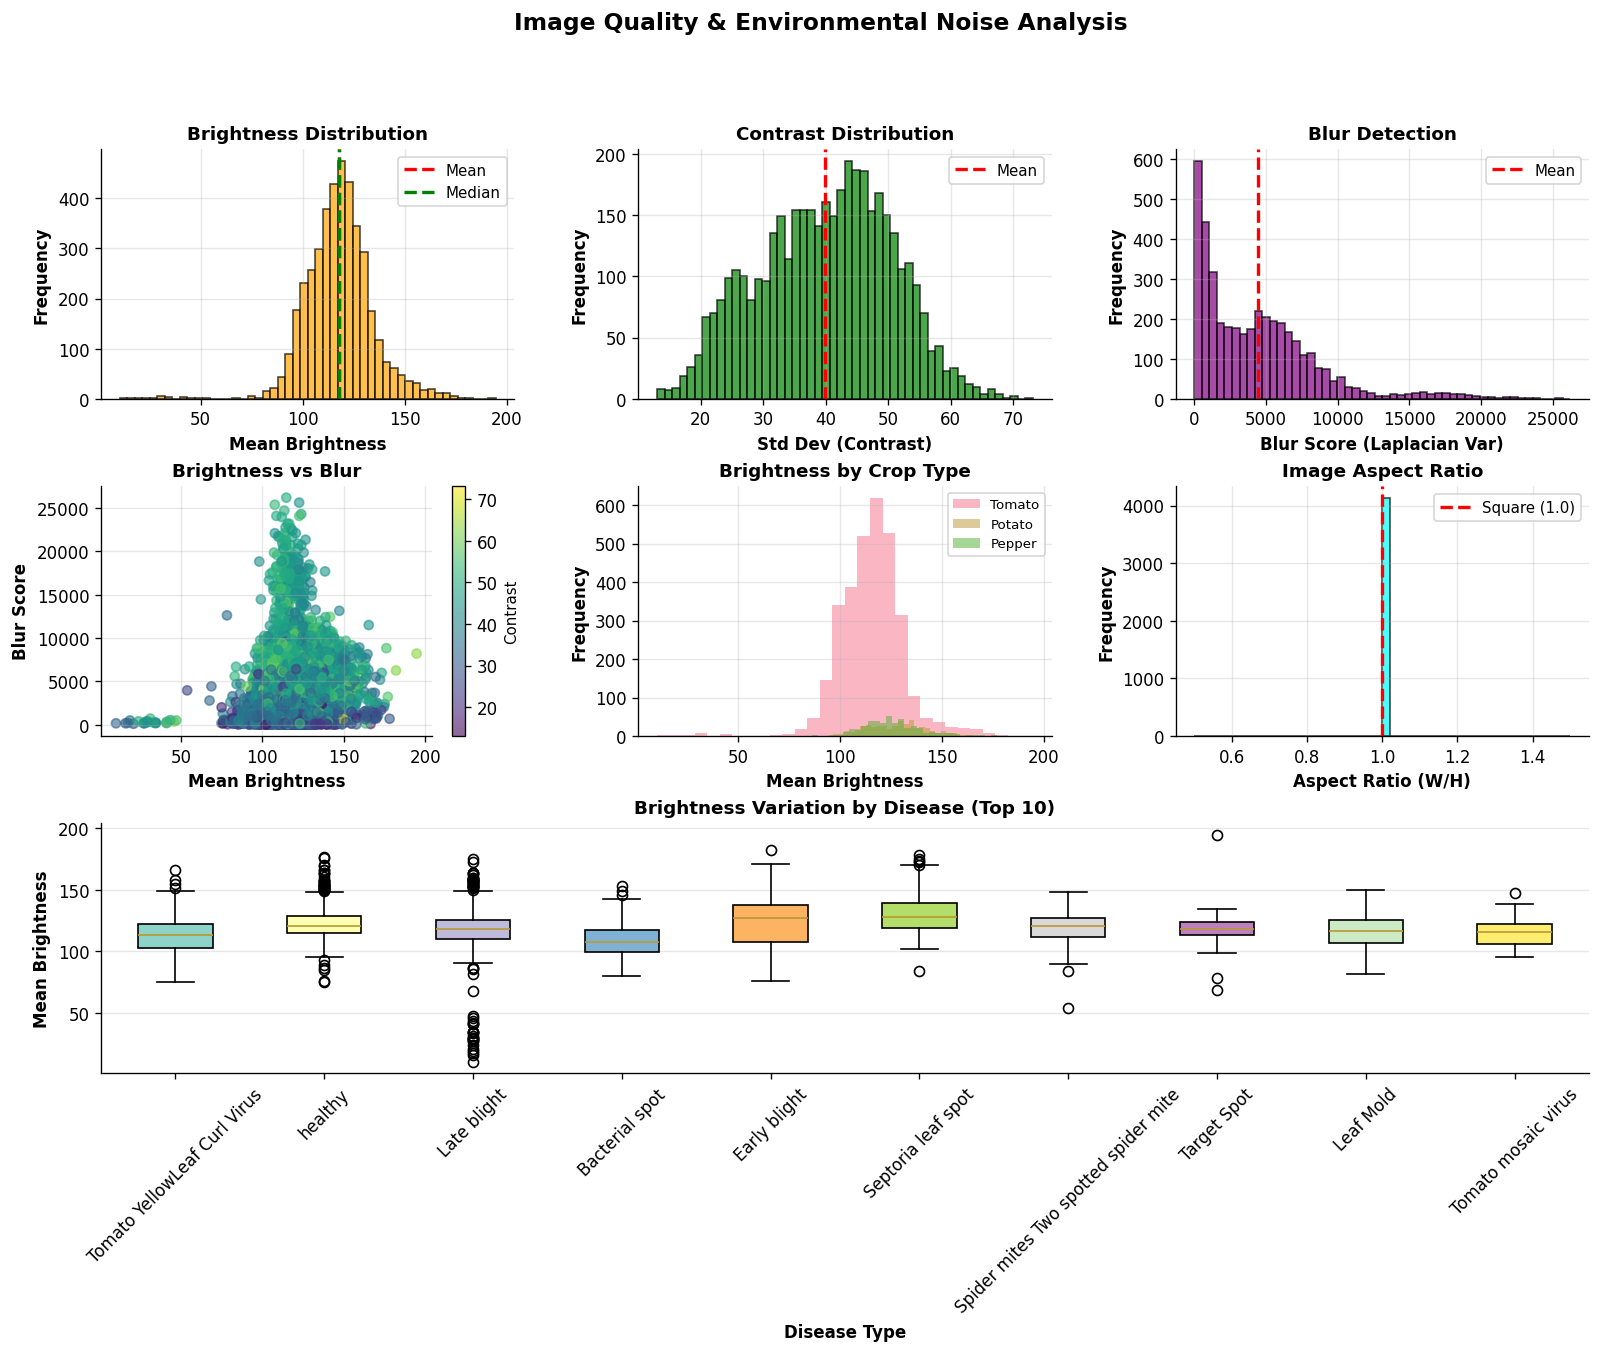

In [8]:
if stats_df is not None:
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    # ── 1. Brightness Distribution ─────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    ax.hist(stats_df['mean_brightness'], bins=50, color='orange', edgecolor='black', alpha=0.7)
    ax.axvline(stats_df['mean_brightness'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    ax.axvline(stats_df['mean_brightness'].median(), color='green', linestyle='--', linewidth=2, label='Median')
    ax.set_xlabel('Mean Brightness', fontsize=10, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=10, fontweight='bold')
    ax.set_title('Brightness Distribution', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # ── 2. Contrast/Std Deviation ──────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    ax.hist(stats_df['std_brightness'], bins=50, color='green', edgecolor='black', alpha=0.7)
    ax.axvline(stats_df['std_brightness'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    ax.set_xlabel('Std Dev (Contrast)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=10, fontweight='bold')
    ax.set_title('Contrast Distribution', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # ── 3. Blur Score (Laplacian Variance) ──────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 2])
    ax.hist(stats_df['blur_score'], bins=50, color='purple', edgecolor='black', alpha=0.7)
    ax.axvline(stats_df['blur_score'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    ax.set_xlabel('Blur Score (Laplacian Var)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=10, fontweight='bold')
    ax.set_title('Blur Detection', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # ── 4. Brightness vs Blur Scatter ──────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    scatter = ax.scatter(stats_df['mean_brightness'], stats_df['blur_score'], 
                         c=stats_df['std_brightness'], cmap='viridis', alpha=0.6, s=30)
    ax.set_xlabel('Mean Brightness', fontsize=10, fontweight='bold')
    ax.set_ylabel('Blur Score', fontsize=10, fontweight='bold')
    ax.set_title('Brightness vs Blur', fontsize=11, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Contrast', fontsize=9)
    ax.grid(alpha=0.3)
    
    # ── 5. Brightness by Crop ──────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 1])
    crops = stats_df['crop'].unique()
    for crop in crops:
        crop_data = stats_df[stats_df['crop'] == crop]['mean_brightness']
        ax.hist(crop_data, bins=30, alpha=0.5, label=crop)
    ax.set_xlabel('Mean Brightness', fontsize=10, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=10, fontweight='bold')
    ax.set_title('Brightness by Crop Type', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
    
    # ── 6. Aspect Ratio Distribution ───────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 2])
    ax.hist(stats_df['aspect_ratio'], bins=50, color='cyan', edgecolor='black', alpha=0.7)
    ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Square (1.0)')
    ax.set_xlabel('Aspect Ratio (W/H)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=10, fontweight='bold')
    ax.set_title('Image Aspect Ratio', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # ── 7. Box plot: Brightness by Disease (top 10) ────────────────────────────────
    ax = fig.add_subplot(gs[2, :])
    top_diseases = stats_df['disease'].value_counts().head(10).index.tolist()
    box_data = [stats_df[stats_df['disease'] == d]['mean_brightness'].values for d in top_diseases]
    bp = ax.boxplot(box_data, labels=top_diseases, patch_artist=True)
    for patch, color in zip(bp['boxes'], plt.cm.Set3(np.linspace(0, 1, 10))):
        patch.set_facecolor(color)
    ax.set_xlabel('Disease Type', fontsize=10, fontweight='bold')
    ax.set_ylabel('Mean Brightness', fontsize=10, fontweight='bold')
    ax.set_title('Brightness Variation by Disease (Top 10)', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    fig.suptitle('Image Quality & Environmental Noise Analysis', 
                fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plot_path = PLOTS_DIR / '03_eda_image_quality_analysis.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: {plot_path}")
    plt.show()

## Image Quality Analysis Report
Use technical metrics to evaluate the visual health of the dataset.

* Brightness & Contrast: Identifies overexposed, dark, or low-contrast images that may hinder feature extraction.
* Blur Detection: Flags potentially out-of-focus samples using Laplacian Variance thresholds.
* Aspect Ratio: Monitors image dimensions to ensure consistency for preprocessing and resizing.

In [9]:
if stats_df is not None:
    print("IMAGE QUALITY ANALYSIS REPORT")
    print("="*80)
    
    # ── Brightness Analysis ────────────────────────────────────────────────────────
    print(f"\n📊 BRIGHTNESS ANALYSIS:")
    print(f"  Mean brightness : {stats_df['mean_brightness'].mean():.1f} (0-255 scale)")
    print(f"  Range           : {stats_df['mean_brightness'].min():.1f} - {stats_df['mean_brightness'].max():.1f}")
    
    dark_pct = (stats_df['mean_brightness'] < 80).sum() / len(stats_df) * 100
    bright_pct = (stats_df['mean_brightness'] > 200).sum() / len(stats_df) * 100
    print(f"  Dark images (<80)      : {dark_pct:.1f}%")
    print(f"  Bright images (>200)   : {bright_pct:.1f}%")
    
    if dark_pct > 20:
        print(f"  ⚠️  WARNING: {dark_pct:.1f}% images are very dark")
    if bright_pct > 20:
        print(f"  ⚠️  WARNING: {bright_pct:.1f}% images are overexposed")
    
    # ── Contrast Analysis ──────────────────────────────────────────────────────────
    print(f"\n📊 CONTRAST ANALYSIS (Std Dev):")
    print(f"  Mean contrast   : {stats_df['std_brightness'].mean():.1f}")
    print(f"  Range           : {stats_df['std_brightness'].min():.1f} - {stats_df['std_brightness'].max():.1f}")
    
    low_contrast = (stats_df['std_brightness'] < 20).sum() / len(stats_df) * 100
    print(f"  Low contrast images    : {low_contrast:.1f}%")
    
    if low_contrast > 10:
        print(f"  ⚠️  WARNING: {low_contrast:.1f}% images have low contrast")
    
    # ── Blur Analysis ──────────────────────────────────────────────────────────────
    print(f"\n📊 BLUR DETECTION (Laplacian Variance):")
    print(f"  Mean blur score : {stats_df['blur_score'].mean():.1f}")
    print(f"  Range           : {stats_df['blur_score'].min():.1f} - {stats_df['blur_score'].max():.1f}")
    
    blurry = (stats_df['blur_score'] < 100).sum() / len(stats_df) * 100
    print(f"  Potentially blurry     : {blurry:.1f}%")
    
    if blurry > 5:
        print(f"  ⚠️  WARNING: {blurry:.1f}% images may be blurry")
    
    # ── Aspect Ratio Analysis ──────────────────────────────────────────────────────
    print(f"\n📊 ASPECT RATIO ANALYSIS:")
    print(f"  Mean aspect ratio : {stats_df['aspect_ratio'].mean():.2f}")
    print(f"  Range             : {stats_df['aspect_ratio'].min():.2f} - {stats_df['aspect_ratio'].max():.2f}")

IMAGE QUALITY ANALYSIS REPORT

📊 BRIGHTNESS ANALYSIS:
  Mean brightness : 117.9 (0-255 scale)
  Range           : 10.3 - 194.6
  Dark images (<80)      : 0.8%
  Bright images (>200)   : 0.0%

📊 CONTRAST ANALYSIS (Std Dev):
  Mean contrast   : 39.9
  Range           : 13.1 - 73.1
  Low contrast images    : 2.3%

📊 BLUR DETECTION (Laplacian Variance):
  Mean blur score : 4448.3
  Range           : 11.7 - 26208.2
  Potentially blurry     : 4.7%

📊 ASPECT RATIO ANALYSIS:
  Mean aspect ratio : 1.00
  Range             : 1.00 - 1.00


## Save EDA Report

In [10]:
print("EDA ANALYSIS COMPLETE")
print("="*80)
print(f"\nOutputs generated:")
print(f"✓ Plots saved to: {PLOTS_DIR}/")

# Save statistics to CSV for future reference
if stats_df is not None:
    stats_csv_path = METADATA_DIR / 'image_quality_stats.csv'
    stats_df.to_csv(stats_csv_path, index=False)
    print(f"✓ Image quality stats saved: {stats_csv_path}")

EDA ANALYSIS COMPLETE

Outputs generated:
✓ Plots saved to: /content/drive/MyDrive/Project2_AgroLens_AI/reports/figures/


✓ Image quality stats saved: /content/drive/MyDrive/Project2_AgroLens_AI/data/metadata/image_quality_stats.csv
